# Pertemuan 5 — Visualisasi Data

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 19 Mei 2026

---

## Tujuan Notebook
Notebook ini dibuat sebagai aktivitas hands-on Pertemuan 5 untuk:
1. Menerapkan 5 prinsip visualisasi data yang efektif (Clarity, Accuracy, Efficiency, Aesthetics, Context)
2. Memilih jenis grafik yang tepat sesuai tujuan komunikasi data
3. Membuat bar chart, histogram, boxplot, dan scatter plot menggunakan Matplotlib & Seaborn
4. Menyusun dashboard visualisasi statis dari dataset **Tips**
5. Membaca grafik secara sistematis menggunakan pendekatan **What? So what? Now what?**

## Setup: Import Library & Load Dataset

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set style global Seaborn
sns.set_theme(style='whitegrid', palette='Set2')

# Load dataset Tips
df = sns.load_dataset('tips')

print('=== INFO DATASET ===')
print(f'Shape  : {df.shape}')
print(f'Kolom  : {list(df.columns)}')
print()
print('=== 5 BARIS PERTAMA ===')
print(df.head())
print()
print('=== TIPE DATA ===')
print(df.dtypes)
print()
print('=== STATISTIK DESKRIPTIF ===')
print(df.describe().round(2))

=== INFO DATASET ===
Shape  : (244, 7)
Kolom  : ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

=== 5 BARIS PERTAMA ===
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

=== TIPE DATA ===
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

=== STATISTIK DESKRIPTIF ===
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


**Deskripsi Dataset Tips:**  
Dataset `tips` berisi 244 baris dan 7 kolom yang merekam data transaksi restoran, meliputi total tagihan (`total_bill`), jumlah tip (`tip`), jenis kelamin pelanggan (`sex`), status merokok (`smoker`), hari (`day`), waktu makan (`time`), dan jumlah tamu di meja (`size`). Dataset ini sangat cocok untuk mengeksplorasi hubungan antara perilaku pengeluaran konsumen dan berbagai faktor demografis.

---
## GRAFIK 1 — Bar Chart: Rata-rata Total Tagihan per Hari

**Tujuan:** Membandingkan nilai rata-rata total tagihan antar kategori hari.  
**Pilihan grafik:** Bar chart dipilih karena tujuannya adalah perbandingan antar kategori diskret (hari).

/tmp/ipykernel_19281/1177504180.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean().reindex(['Thur','Fri','Sat','Sun'])


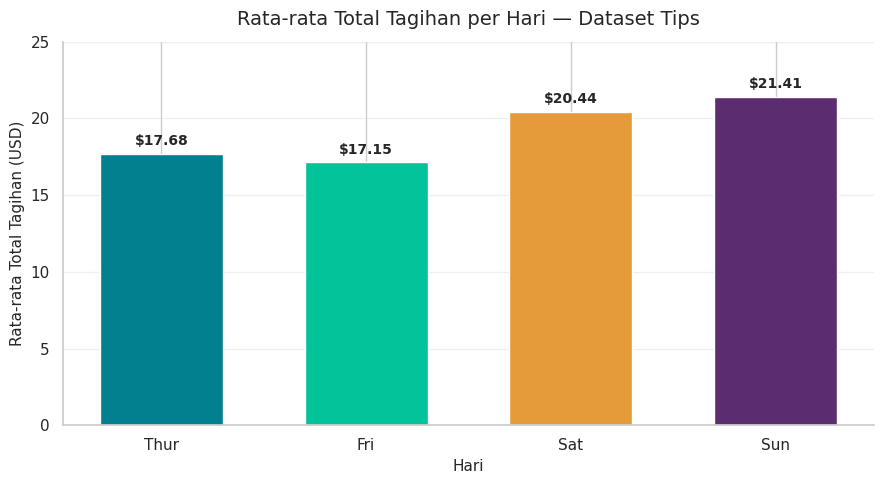

Grafik 1 tersimpan.


In [2]:
# GRAFIK 1: Bar Chart — Rata-rata Total Tagihan per Hari
avg_by_day = df.groupby('day')['total_bill'].mean().reindex(['Thur','Fri','Sat','Sun'])

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(avg_by_day.index, avg_by_day.values,
              color=['#028090','#02C39A','#E69B3A','#5B2C6F'],
              edgecolor='white', width=0.6)

# Label nilai di atas setiap bar
ax.bar_label(bars, fmt='$%.2f', padding=4, fontsize=10, fontweight='bold')

ax.set_title('Rata-rata Total Tagihan per Hari — Dataset Tips', fontsize=14, pad=12)
ax.set_xlabel('Hari', fontsize=11)
ax.set_ylabel('Rata-rata Total Tagihan (USD)', fontsize=11)
ax.set_ylim(0, 25)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('grafik1_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik 1 tersimpan.')

### Insight Grafik 1 — What? So what? Now what?

**What (Apa yang terlihat)?**  
Grafik batang ini menampilkan rata-rata total tagihan (USD) untuk empat hari operasional restoran (Kamis–Minggu) dari 244 transaksi dataset Tips. Nilai berkisar antara sekitar \$17 (Jumat) hingga sekitar \$21 (Sabtu dan Minggu).

**So what (Mengapa ini penting)?**  
Sabtu dan Minggu memiliki rata-rata tagihan tertinggi (~\$20–21), sementara Jumat adalah hari dengan rata-rata tagihan terendah (~\$17). Hal ini mengindikasikan bahwa pelanggan akhir pekan cenderung memesan lebih banyak, kemungkinan karena makan bersama keluarga atau kelompok yang lebih besar. Kamis dan Jumat menunjukkan pola yang lebih hemat, mungkin karena didominasi pelanggan makan siang pekerja kantoran.

**Now what (Tindak lanjut)?**  
Manajemen restoran perlu memastikan kapasitas staf dan stok bahan yang lebih besar di akhir pekan untuk memaksimalkan potensi pendapatan. Perlu juga dieksplorasi apakah perbedaan ini konsisten lintas musim atau hanya terjadi di periode tertentu dalam setahun.

---
## GRAFIK 2 — Histogram + KDE: Distribusi Total Tagihan per Waktu Makan

**Tujuan:** Memahami distribusi satu variabel numerik dan membandingkannya antar kelompok.  
**Pilihan grafik:** Histogram + KDE dipilih karena tujuannya adalah melihat sebaran (distribusi) satu variabel numerik.

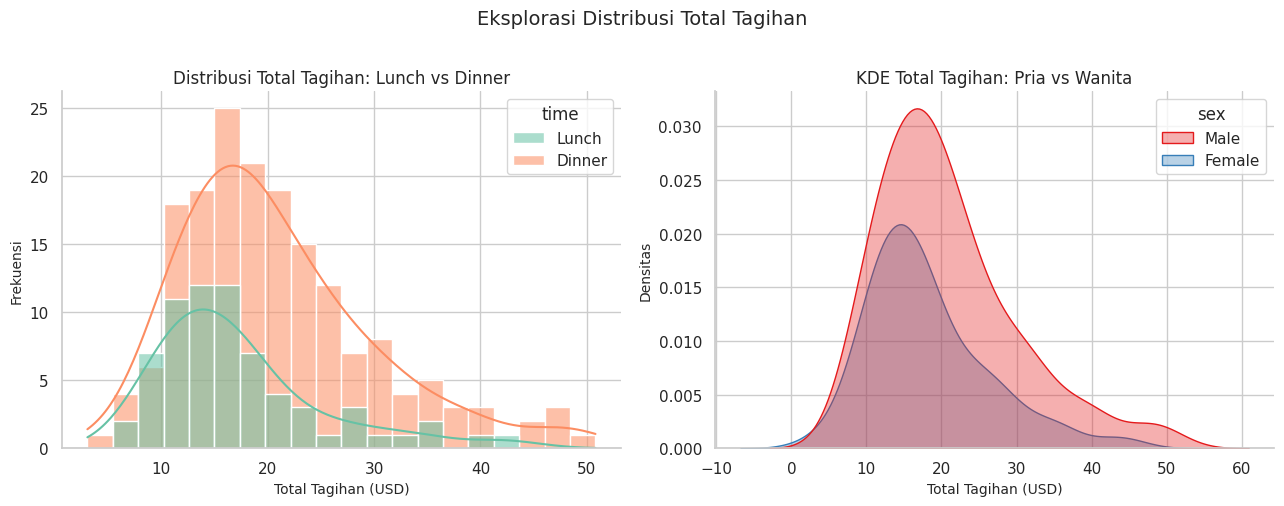

Grafik 2 tersimpan.


In [3]:
# GRAFIK 2: Histogram + KDE — Distribusi Total Tagihan per Waktu Makan
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kiri: Histogram + KDE gabungan (Lunch vs Dinner)
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.55,
             bins=20, ax=axes[0])
axes[0].set_title('Distribusi Total Tagihan: Lunch vs Dinner', fontsize=12)
axes[0].set_xlabel('Total Tagihan (USD)', fontsize=10)
axes[0].set_ylabel('Frekuensi', fontsize=10)
axes[0].spines[['top', 'right']].set_visible(False)

# Kanan: KDE saja per jenis kelamin
sns.kdeplot(data=df, x='total_bill', hue='sex',
            fill=True, palette='Set1', alpha=0.35,
            ax=axes[1])
axes[1].set_title('KDE Total Tagihan: Pria vs Wanita', fontsize=12)
axes[1].set_xlabel('Total Tagihan (USD)', fontsize=10)
axes[1].set_ylabel('Densitas', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Eksplorasi Distribusi Total Tagihan', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('grafik2_histogram_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik 2 tersimpan.')

### Insight Grafik 2 — What? So what? Now what?

**What (Apa yang terlihat)?**  
Panel kiri menampilkan histogram dan kurva KDE total tagihan (USD) untuk dua waktu makan (Lunch dan Dinner) dari seluruh 244 transaksi. Panel kanan menunjukkan kurva KDE yang dibandingkan antara pelanggan pria dan wanita. Rentang tagihan berkisar dari sekitar \$3 hingga \$50.

**So what (Mengapa ini penting)?**  
Distribusi total tagihan bersifat *right-skewed* (menceng ke kanan), artinya sebagian besar transaksi bernilai rendah–menengah (\$10–25) tetapi ada ekor panjang ke kanan dengan transaksi bernilai tinggi. Dinner secara konsisten memiliki tagihan yang lebih besar dibanding Lunch, yang terlihat dari distribusi Dinner yang lebih menyebar ke kanan. Dari sisi gender, distribusi pria dan wanita cukup serupa, meskipun pria menunjukkan lebih banyak frekuensi di transaksi bernilai tinggi.

**Now what (Tindak lanjut)?**  
Restoran dapat mempertimbangkan paket makan siang yang lebih kompetitif untuk mendorong nilai tagihan Lunch mendekati Dinner. Analisis lanjutan perlu dilakukan untuk melihat apakah perbedaan gender juga tercermin dalam perilaku tip, bukan hanya total tagihan.

---
## GRAFIK 3 — Boxplot & Violin Plot: Distribusi Tagihan per Hari dan Gender

**Tujuan:** Membandingkan distribusi variabel numerik antar beberapa kelompok sekaligus.  
**Pilihan grafik:** Boxplot dan violin plot dipilih karena mampu menampilkan ringkasan statistik (median, IQR, outlier) dan bentuk distribusi per kategori.

/tmp/ipykernel_19281/4259308573.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='day', y='total_bill',


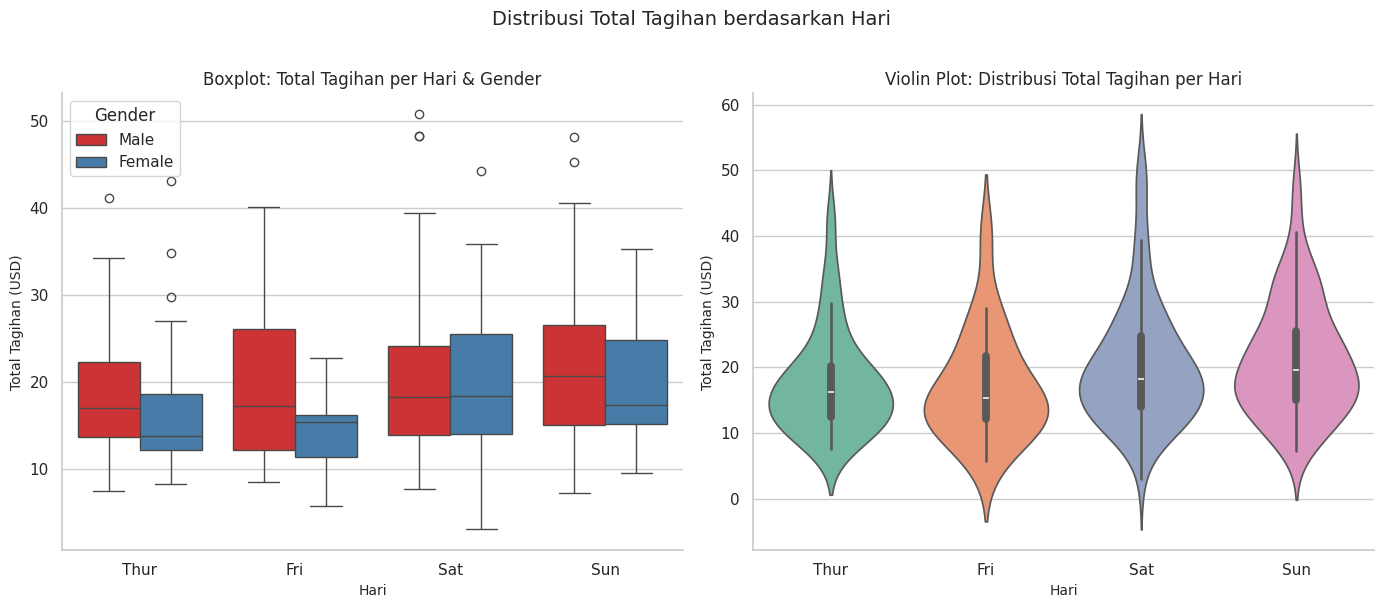

Grafik 3 tersimpan.


In [4]:
# GRAFIK 3: Boxplot & Violin Plot — Distribusi Tagihan per Hari & Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot: tagihan per hari, dibedakan gender
sns.boxplot(data=df, x='day', y='total_bill', hue='sex',
            palette='Set1', order=['Thur','Fri','Sat','Sun'],
            ax=axes[0])
axes[0].set_title('Boxplot: Total Tagihan per Hari & Gender', fontsize=12)
axes[0].set_xlabel('Hari', fontsize=10)
axes[0].set_ylabel('Total Tagihan (USD)', fontsize=10)
axes[0].legend(title='Gender')
axes[0].spines[['top', 'right']].set_visible(False)

# Violin plot: tagihan per hari
sns.violinplot(data=df, x='day', y='total_bill',
               palette='Set2', inner='box',
               order=['Thur','Fri','Sat','Sun'],
               ax=axes[1])
axes[1].set_title('Violin Plot: Distribusi Total Tagihan per Hari', fontsize=12)
axes[1].set_xlabel('Hari', fontsize=10)
axes[1].set_ylabel('Total Tagihan (USD)', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribusi Total Tagihan berdasarkan Hari', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('grafik3_boxplot_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik 3 tersimpan.')

### Insight Grafik 3 — What? So what? Now what?

**What (Apa yang terlihat)?**  
Grafik kiri menampilkan boxplot total tagihan (USD) per hari yang dibedakan berdasarkan gender pelanggan. Grafik kanan menampilkan violin plot yang menunjukkan distribusi penuh tagihan per hari. Keduanya mencakup 244 transaksi, dengan rentang nilai tagihan \$3 hingga \$50.

**So what (Mengapa ini penting)?**  
Boxplot menunjukkan bahwa Sabtu dan Minggu memiliki sebaran tagihan yang lebih luas (IQR lebih besar) dibanding hari kerja, serta lebih banyak outlier di tagihan tinggi — konsisten dengan temuan grafik sebelumnya. Pelanggan pria umumnya memiliki tagihan median yang sedikit lebih tinggi dari wanita di hampir semua hari. Violin plot Sabtu dan Minggu memperlihatkan distribusi bimodal ringan, mengindikasikan adanya dua pola pengeluaran berbeda (meja kecil vs meja besar) yang terjadi di hari yang sama.

**Now what (Tindak lanjut)?**  
Perbedaan pola distribusi antara hari kerja dan akhir pekan perlu menjadi pertimbangan dalam strategi penetapan harga dan promosi. Adanya pola bimodal di akhir pekan layak diinvestigasi lebih lanjut dengan menganalisis kolom `size` (jumlah tamu per meja) untuk mengkonfirmasi hipotesis meja kecil vs meja besar.

---
## GRAFIK 4 — Scatter Plot: Hubungan Total Tagihan & Tip

**Tujuan:** Mengeksplorasi hubungan (korelasi) antara dua variabel numerik.  
**Pilihan grafik:** Scatter plot dipilih karena tujuannya adalah melihat hubungan dua variabel, dengan ukuran titik sebagai dimensi ketiga (jumlah tamu).

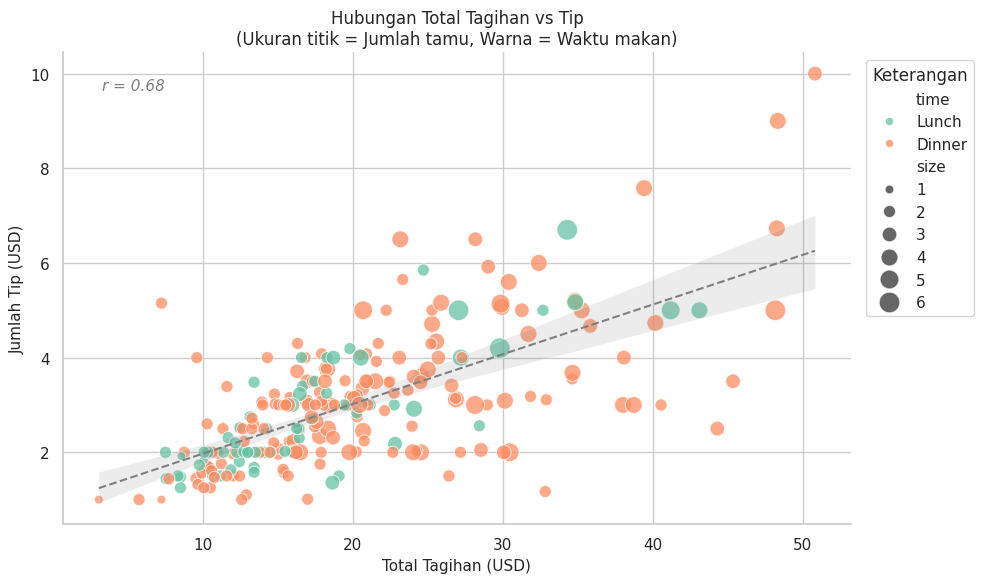

Korelasi Pearson total_bill vs tip: r = 0.6757
Grafik 4 tersimpan.


In [5]:
# GRAFIK 4: Scatter Plot — Hubungan Total Tagihan & Tip
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot: warna = waktu makan, ukuran = jumlah tamu
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size',
                sizes=(40, 220), palette='Set2',
                alpha=0.75, ax=ax)

# Garis regresi keseluruhan
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray',
            line_kws={'linestyle': '--', 'linewidth': 1.5},
            ax=ax)

# Hitung korelasi Pearson
corr = df['total_bill'].corr(df['tip'])
ax.annotate(f'r = {corr:.2f}', xy=(0.05, 0.92),
            xycoords='axes fraction', fontsize=11,
            color='gray', fontstyle='italic')

ax.set_title('Hubungan Total Tagihan vs Tip\n(Ukuran titik = Jumlah tamu, Warna = Waktu makan)',
             fontsize=12)
ax.set_xlabel('Total Tagihan (USD)', fontsize=11)
ax.set_ylabel('Jumlah Tip (USD)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Keterangan', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('grafik4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Korelasi Pearson total_bill vs tip: r = {corr:.4f}')
print('Grafik 4 tersimpan.')

### Insight Grafik 4 — What? So what? Now what?

**What (Apa yang terlihat)?**  
Scatter plot menampilkan hubungan antara total tagihan (sumbu X) dan jumlah tip (sumbu Y) untuk 244 transaksi. Warna titik membedakan waktu makan (Lunch/Dinner), ukuran titik merepresentasikan jumlah tamu di meja, dan garis putus-putus abu-abu adalah garis regresi linear dengan nilai korelasi Pearson r ≈ 0.68.

**So what (Mengapa ini penting)?**  
Terdapat hubungan positif yang cukup kuat (r = 0.68) antara total tagihan dan jumlah tip: semakin besar tagihan, semakin besar pula tip yang diberikan. Namun, ada variasi yang cukup besar di sekitar garis regresi, artinya tagihan bukan satu-satunya penentu besarnya tip. Titik berukuran besar (meja ramai) cenderung menghasilkan tip yang lebih besar, dan transaksi Dinner (warna oranye) umumnya berada di area tagihan lebih tinggi.

**Now what (Tindak lanjut)?**  
Restoran dapat mempertimbangkan strategi yang mendorong kepuasan layanan di meja besar karena potensi tip lebih tinggi. Perlu juga dianalisis variabel lain (hari, status merokok) untuk membangun model prediksi tip yang lebih akurat — ini bisa menjadi dasar untuk sistem rekomendasi jadwal staf terbaik.

---
## DASHBOARD VISUALISASI STATIS

Menggabungkan keempat grafik di atas ke dalam satu layout dashboard untuk komunikasi temuan secara komprehensif.

/tmp/ipykernel_19281/1644376281.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean().reindex(['Thur','Fri','Sat','Sun'])


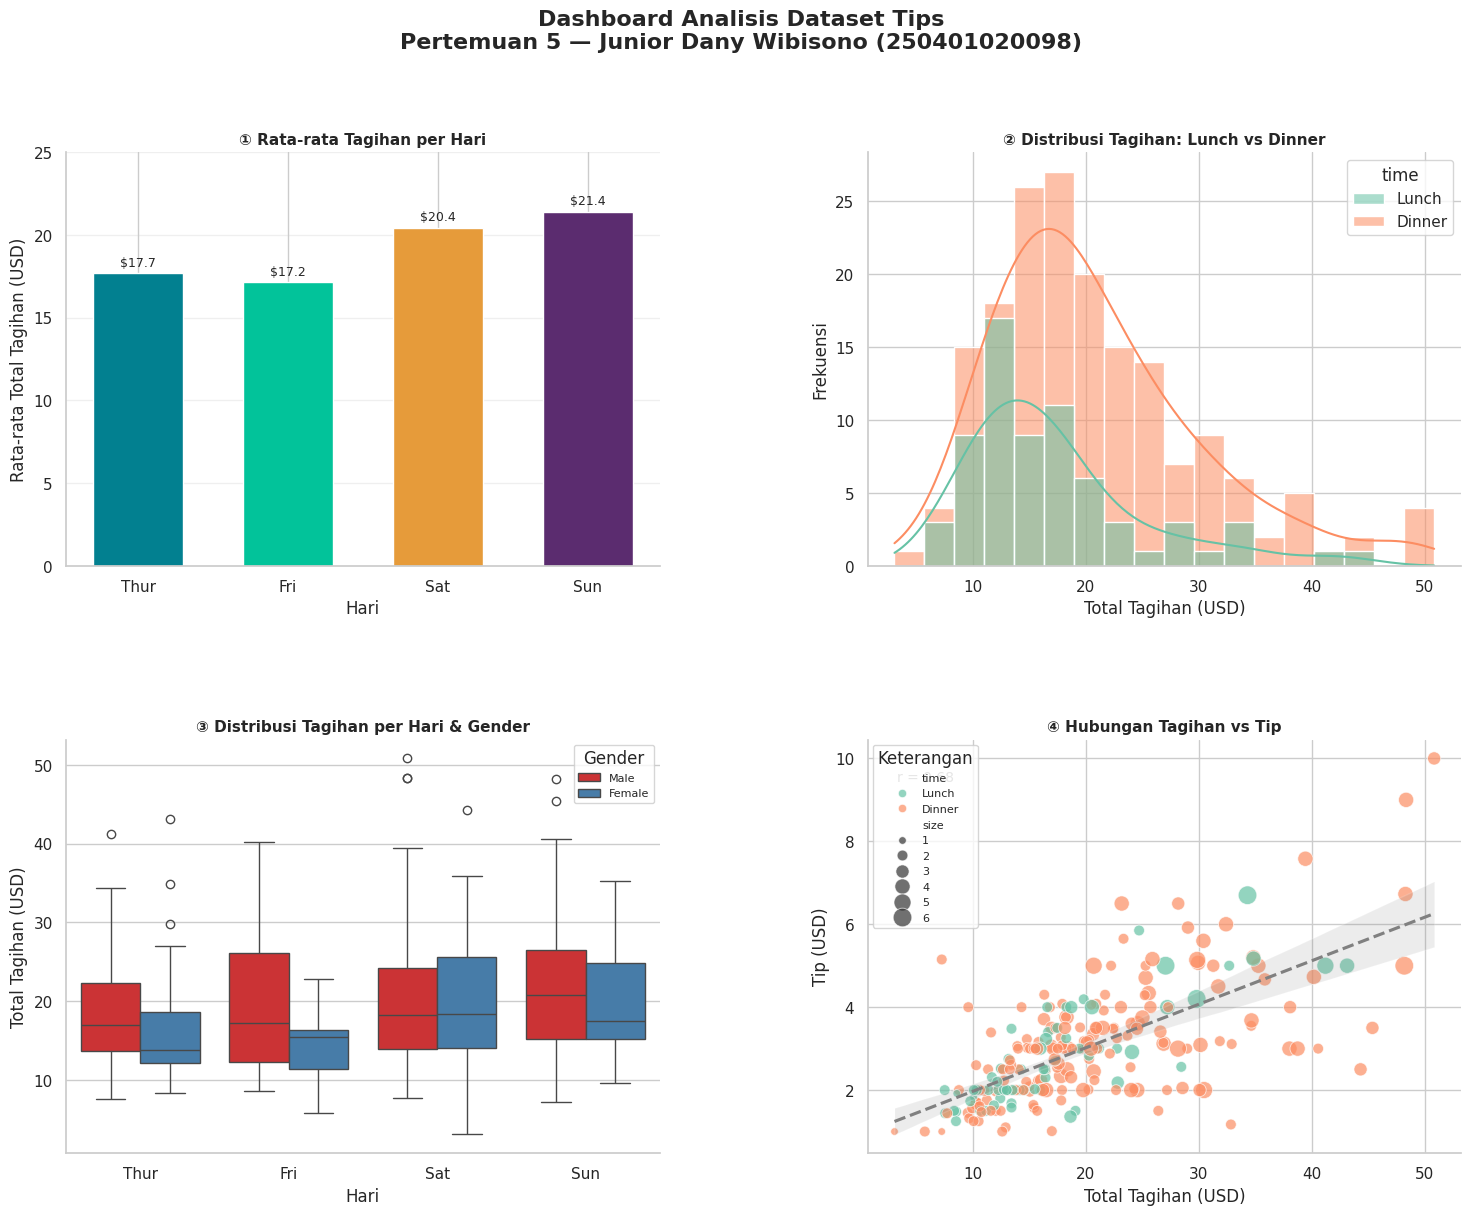

Dashboard tersimpan sebagai dashboard_tips.png


In [6]:
# DASHBOARD VISUALISASI STATIS — Dataset Tips
fig = plt.figure(figsize=(18, 13))
fig.suptitle('Dashboard Analisis Dataset Tips\nPertemuan 5 — Junior Dany Wibisono (250401020098)',
             fontsize=16, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── Panel 1: Bar Chart ──────────────────────────────────────────────────
avg_by_day = df.groupby('day')['total_bill'].mean().reindex(['Thur','Fri','Sat','Sun'])
bars = ax1.bar(avg_by_day.index, avg_by_day.values,
               color=['#028090','#02C39A','#E69B3A','#5B2C6F'],
               edgecolor='white', width=0.6)
ax1.bar_label(bars, fmt='$%.1f', padding=3, fontsize=9)
ax1.set_title('① Rata-rata Tagihan per Hari', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Rata-rata Total Tagihan (USD)')
ax1.set_ylim(0, 25)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Histogram + KDE ────────────────────────────────────────────
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.55,
             bins=18, ax=ax2)
ax2.set_title('② Distribusi Tagihan: Lunch vs Dinner', fontsize=11, fontweight='bold')
ax2.set_xlabel('Total Tagihan (USD)'); ax2.set_ylabel('Frekuensi')
ax2.spines[['top','right']].set_visible(False)

# ── Panel 3: Boxplot ────────────────────────────────────────────────────
sns.boxplot(data=df, x='day', y='total_bill', hue='sex',
            palette='Set1', order=['Thur','Fri','Sat','Sun'], ax=ax3)
ax3.set_title('③ Distribusi Tagihan per Hari & Gender', fontsize=11, fontweight='bold')
ax3.set_xlabel('Hari'); ax3.set_ylabel('Total Tagihan (USD)')
ax3.legend(title='Gender', fontsize=8)
ax3.spines[['top','right']].set_visible(False)

# ── Panel 4: Scatter Plot ───────────────────────────────────────────────
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size',
                sizes=(30, 180), palette='Set2',
                alpha=0.7, ax=ax4, legend='brief')
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray',
            line_kws={'linestyle': '--'}, ax=ax4)
corr = df['total_bill'].corr(df['tip'])
ax4.annotate(f'r = {corr:.2f}', xy=(0.05, 0.90),
             xycoords='axes fraction', fontsize=10, color='gray')
ax4.set_title('④ Hubungan Tagihan vs Tip', fontsize=11, fontweight='bold')
ax4.set_xlabel('Total Tagihan (USD)'); ax4.set_ylabel('Tip (USD)')
ax4.spines[['top','right']].set_visible(False)
ax4.legend(fontsize=8, title='Keterangan')

plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

---
## Analisis Tambahan: Heatmap Korelasi

Eksplorasi tambahan menggunakan heatmap untuk melihat korelasi antar semua variabel numerik sekaligus.

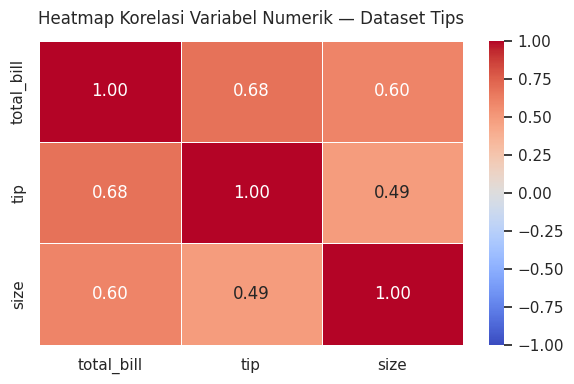

Matriks Korelasi:
            total_bill    tip   size
total_bill       1.000  0.676  0.598
tip              0.676  1.000  0.489
size             0.598  0.489  1.000


In [7]:
# Heatmap korelasi variabel numerik
numerik = df[['total_bill', 'tip', 'size']]
corr_matrix = numerik.corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Heatmap Korelasi Variabel Numerik — Dataset Tips', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('grafik5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Matriks Korelasi:')
print(corr_matrix.round(3))

**Insight Heatmap:**  
Heatmap mengkonfirmasi bahwa `total_bill` dan `tip` memiliki korelasi positif paling kuat (r = 0.68), diikuti oleh `total_bill` dan `size` (r = 0.60), dan `tip` dengan `size` (r = 0.49). Artinya, ketiga variabel ini saling berkaitan: meja yang lebih ramai cenderung menghasilkan tagihan dan tip yang lebih besar.

---
## Refleksi Singkat

Melalui aktivitas hands-on Pertemuan 5 ini, saya berhasil:

1. **Menerapkan 5 prinsip visualisasi efektif** — setiap grafik memiliki judul deskriptif, label sumbu dengan satuan, sumbu Y dimulai dari 0 (untuk bar chart), warna bermakna, dan meminimalkan chartjunk.
2. **Memilih jenis grafik yang tepat** — bar chart untuk perbandingan kategori, histogram+KDE untuk distribusi, boxplot+violin untuk distribusi per kelompok, dan scatter plot untuk hubungan dua variabel.
3. **Menggunakan Matplotlib dan Seaborn** secara bersamaan: Seaborn untuk grafik statistik yang ringkas, dan Matplotlib untuk kustomisasi layout dashboard.
4. **Menarik insight yang actionable** menggunakan kerangka **What? So what? Now what?** pada setiap grafik — tidak hanya mendeskripsikan visual, tetapi juga memaknai dan merekomendasikan tindak lanjut.

Pengalaman ini memperkuat pemahaman saya bahwa visualisasi data bukan sekadar membuat grafik yang cantik, melainkan alat komunikasi untuk mengubah angka mentah menjadi keputusan yang bermakna — sebuah kompetensi inti seorang Data Scientist.

---
**Keterbatasan & Pertanyaan:** Dashboard yang dibuat bersifat statis — tidak interaktif. Pertanyaan yang muncul: kapan sebaiknya beralih ke library interaktif seperti Plotly atau Bokeh? Bagaimana cara menentukan palet warna yang ramah bagi penyandang buta warna (*colorblind-friendly*)?